# Heat equations: eigenfunction expansions

We solve a homogeneous Dirichlet heat problem on $0<x<\pi$ with $u(x,0)=x(\pi-x)$. The example makes the verification semantics of a truncated Fourier series explicit.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. Separation-of-variables DerivationWriting $u=X(x)T(t)$ in $u_t=u_{xx}$ gives$$\frac{T'}{T}=\frac{X''}{X}=-n^2.$$Homogeneous Dirichlet data on $[0,\pi]$ select $X_n=\sin(nx)$ and $T_n=e^{-n^2t}$. Thus$$u_N(x,t)=\sum_{n=1}^N b_n e^{-n^2t}\sin(nx),\qquadb_n=\frac{2}{\pi}\int_0^\pi x(\pi-x)\sin(nx)\,dx.$$

In [3]:
x, t, n = sp.symbols("x t n", positive=True, real=True)
u = sp.Function("u")
eq = sp.Eq(sp.diff(u(x,t),t), sp.diff(u(x,t),x,2))
ics = {"initial_profile": lambda z: z*(sp.pi-z)}
bcs = {"type":"dirichlet_homogeneous_interval", "length":sp.pi, "terms":5}
problem = pds.build_pde_problem(eq, u(x,t), (x,t), ics=ics, bcs=bcs)
recognition, plan = show_plan(problem)
b1 = sp.simplify(2/sp.pi*sp.integrate(x*(sp.pi-x)*sp.sin(x),(x,0,sp.pi)))
print("First sine coefficient:", b1)

Recognition: (PDERecognitionRecord(family='heat_like', recognized=True, solver_hint='heat_dirichlet_series', tags=('separation_of_variables', 'integral_transform'), metadata={}),)Top plan steps:  heat_dirichlet_series                      score=96  constant_coefficient_inverse_operator      score=84  symmetry_reduction                         score=60  post_reduction_auto                        score=48  classification_only                        score=20First sine coefficient: 8/pi

PDESolutionRecord heat_dirichlet_sine_series

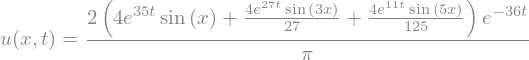

Verification: {'verified': False, 'status': 'failed', 'pde_verified': True, 'initial_verified': False, 'boundary_verified': True, 'pde_residual': 0, 'initial_residuals': ((3375*pi*x*(x - pi) + 27000*sin(x) + 1000*sin(3*x) + 216*sin(5*x))/(3375*pi),), 'boundary_residuals': (0, 0), 'mode': 'symbolic', 'message': ''}

In [4]:
result = pds.pdesolve(eq, u(x,t), (x,t), ics=ics, bcs=bcs, method="auto")
print(type(result).__name__, result.method)
display(result.solution)
print("Verification:", result.verification)

In [5]:
sol = rhs_of(result.solution)
print("PDE residual:", sp.simplify(sp.diff(sol,t)-sp.diff(sol,x,2)))
print("Boundary x=0:", sp.simplify(sol.subs(x,0)))
print("Boundary x=pi:", sp.simplify(sol.subs(x,sp.pi)))
initial_error = sp.simplify(sol.subs(t,0)-x*(sp.pi-x))
print("Finite-series initial residual is identically zero?", initial_error == 0)
assert sp.simplify(sp.diff(sol,t)-sp.diff(sol,x,2)) == 0

PDE residual: 0Boundary x=0: 0Boundary x=pi: 0Finite-series initial residual is identically zero? False

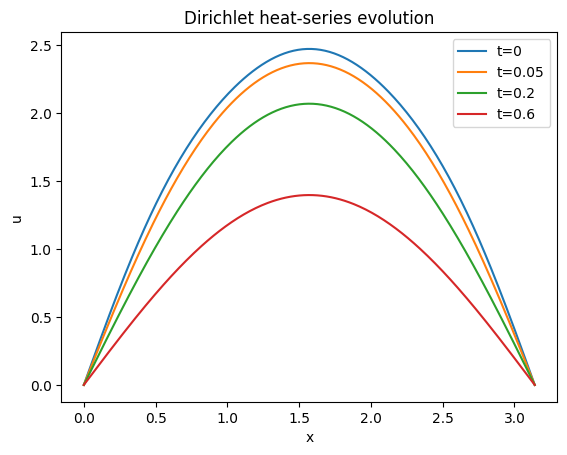

In [6]:
f = sp.lambdify((x,t), sol, "numpy")
xx = np.linspace(0, float(sp.pi), 300)
fig, ax = plt.subplots()
for tv in [0.0, 0.05, 0.2, 0.6]:
    ax.plot(xx, f(xx,tv), label=f"t={tv:g}")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_title("Dirichlet heat-series evolution")
ax.legend(); plt.show()

## 3. Variation and exercisesIncrease the truncation from 5 to 15 modes below. Then: (1) quantify the maximum initial-profile error versus mode count; (2) repeat with Neumann data; (3) explain why every finite truncation satisfies the PDE exactly even though it only approximates the initial function.

In [7]:
bcs15 = dict(bcs); bcs15["terms"] = 15
r2 = pds.pdesolve(eq, u(x,t), (x,t), ics=ics, bcs=bcs15, method="auto")
print(r2.method); print("Expression length:", len(str(r2.solution)))

heat_dirichlet_sine_seriesExpression length: 102